# AI Programming Foundations Project

Student: Grant Collings

Dataset: Cincinnati Fire Incidents (CAD) including EMS ALS/BLS

This notebook builds a reproducible data workflow using public Cincinnati Fire/EMS CAD incident data. The workflow loads the dataset, inspects its structure, cleans selected fields, performs exploratory data analysis, creates visualizations, and summarizes key findings and limitations.

## 1. Import Libraries

This section imports the Python libraries used for data loading, cleaning, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load the Dataset

The dataset is loaded from the local CSV file included with this repository.

In [2]:
DATA_PATH = "cincinnati_fire_incidents_2025.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (97881, 17)


,ADDRESS_X,LATITUDE_X,LONGITUDE_X,AGENCY,CREATE_TIME_INCIDENT,DISPOSITION_TEXT,EVENT_NUMBER,INCIDENT_TYPE_ID,INCIDENT_TYPE_DESC,NEIGHBORHOOD,ARRIVAL_TIME_PRIMARY_UNIT,BEAT,CLOSED_TIME_INCIDENT,DISPATCH_TIME_PRIMARY_UNIT,CFD_INCIDENT_TYPE,CFD_INCIDENT_TYPE_GROUP,COMMUNITY_COUNCIL_NEIGHBORHOOD
0,BROADWAY,39.107948,-84.506636,CFD,2025 Jan 01 12:04:08 AM,PRF: PATIENT REFUSED EVAL/CARE,CFD250101000002,=EMS,NaN,PENDLETON,NaN,ST03,2025 Jan 01 12:17:05 AM,2025 Jan 01 12:04:28 AM,NaN,NaN,DOWNTOWN - PENDLETON
1,INNES AV,39.169770,-84.545520,CFD,2025 Jan 01 12:10:22 AM,TRL: TRANSPORT - LIGHTS/SIREN,CFD250101000003,=SHOOT - (C),NaN,NORTHSIDE,01/01/2025 12:18:04 AM,ST20,2025 Jan 01 01:12:20 AM,NaN,NaN,NaN,NORTHSIDE
2,INNES AV,39.170470,-84.545410,CFD,2025 Jan 01 12:11:07 AM,DUPF: DUPLICATE,CFD250101000004,CAD2CAD,NaN,NORTHSIDE,NaN,ST20,2025 Jan 01 12:11:52 AM,NaN,NaN,NaN,NORTHSIDE
3,MOERLEIN AV,39.127770,-84.517090,CFD,2025 Jan 01 12:18:04 AM,EXT: EXTINGUISH,CFD250101000005,OUTDR - 67B1,NaN,CUF,01/01/2025 12:22:03 AM,ST19,2025 Jan 01 12:24:45 AM,2025 Jan 01 12:18:21 AM,NaN,NaN,CUF
4,STANTON AV,39.128825,-84.491235,CFD,2025 Jan 01 12:18:05 AM,TRL: TRANSPORT - LIGHTS/SIREN,CFD250101000006,ACCI - (C) =,NaN,WALNUT HILLS,01/01/2025 12:21:57 AM,ST23,2025 Jan 01 12:59:03 AM,2025 Jan 01 12:18:20 AM,NaN,NaN,WALNUT HILLS


## 3. Initial Data Inspection

This section reviews column names, data types, and missing values before cleaning.

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns:
['ADDRESS_X', 'LATITUDE_X', 'LONGITUDE_X', 'AGENCY', 'CREATE_TIME_INCIDENT', 'DISPOSITION_TEXT', 'EVENT_NUMBER', 'INCIDENT_TYPE_ID', 'INCIDENT_TYPE_DESC', 'NEIGHBORHOOD', 'ARRIVAL_TIME_PRIMARY_UNIT', 'BEAT', 'CLOSED_TIME_INCIDENT', 'DISPATCH_TIME_PRIMARY_UNIT', 'CFD_INCIDENT_TYPE', 'CFD_INCIDENT_TYPE_GROUP', 'COMMUNITY_COUNCIL_NEIGHBORHOOD']

Data types:
ADDRESS_X                             str
LATITUDE_X                        float64
LONGITUDE_X                       float64
AGENCY                                str
CREATE_TIME_INCIDENT                  str
DISPOSITION_TEXT                      str
EVENT_NUMBER                          str
INCIDENT_TYPE_ID                      str
INCIDENT_TYPE_DESC                    str
NEIGHBORHOOD                          str
ARRIVAL_TIME_PRIMARY_UNIT             str
BEAT                                  str
CLOSED_TIME_INCIDENT                  str
DISPATCH_TIME_PRIMARY_UNIT            str
CFD_INCIDENT_TYPE                     str
CFD_

In [4]:
df.describe(include="all")

,ADDRESS_X,LATITUDE_X,LONGITUDE_X,AGENCY,CREATE_TIME_INCIDENT,DISPOSITION_TEXT,EVENT_NUMBER,INCIDENT_TYPE_ID,INCIDENT_TYPE_DESC,NEIGHBORHOOD,ARRIVAL_TIME_PRIMARY_UNIT,BEAT,CLOSED_TIME_INCIDENT,DISPATCH_TIME_PRIMARY_UNIT,CFD_INCIDENT_TYPE,CFD_INCIDENT_TYPE_GROUP,COMMUNITY_COUNCIL_NEIGHBORHOOD
count,97873,97881.000000,97881.000000,97881,97881,96658,97881,97461,5053,97249,84564,97875,95096,89829,5054,5054,97259
unique,6807,NaN,NaN,1,97727,54,97881,878,8,50,84446,28,94903,89757,3,7,69
top,READING RD,NaN,NaN,CFD,2025 Jan 05 08:14:47 PM,TRL: TRANSPORT - LIGHTS/SIREN,CFD250101000002,EMS,ILLNESS/PROQA TRIGGER FOR EMD PROTOCOLS,WESTWOOD,01/03/2025 09:11:31 AM,ST35,2025 Feb 20 12:21:06 PM,2025 Jan 09 08:38:51 PM,BLS,MEDICAL EMERGENCY,WESTWOOD
freq,2679,NaN,NaN,97881,2,28650,1,4792,4792,8092,2,7251,3,2,5025,4792,8216
mean,NaN,39.140640,-84.514958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.031932,0.056004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,38.885378,-84.814294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,39.114401,-84.553530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,39.136114,-84.515069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,39.159306,-84.485230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Cleaning Functions

Project 2 requires at least two cleaning functions with docstrings. These functions clean text fields and convert incident time columns into datetime values.

In [5]:
def clean_text_columns(dataframe):
    """Return a copy of the dataframe with selected text columns cleaned.

    This function strips extra spaces and standardizes empty text values as missing values.
    It helps make grouping and counting more consistent during exploratory analysis.
    """
    cleaned = dataframe.copy()
    text_columns = [column for column in cleaned.columns if pd.api.types.is_object_dtype(cleaned[column]) or pd.api.types.is_string_dtype(cleaned[column])]

    for column in text_columns:
        cleaned[column] = cleaned[column].astype("string").str.strip()
        cleaned[column] = cleaned[column].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

    return cleaned


def convert_time_columns(dataframe):
    """Return a copy of the dataframe with incident time columns converted to datetime.

    The source CSV stores time fields as text. Converting them to datetime values allows
    time-based analysis such as incident hour, day of week, and response interval calculations.
    """
    cleaned = dataframe.copy()
    time_columns = [
        "CREATE_TIME_INCIDENT",
        "DISPATCH_TIME_PRIMARY_UNIT",
        "ARRIVAL_TIME_PRIMARY_UNIT",
        "CLOSED_TIME_INCIDENT",
    ]

    for column in time_columns:
        cleaned[column] = pd.to_datetime(cleaned[column], format="mixed", errors="coerce")

    return cleaned

In [6]:
cleaned_df = clean_text_columns(df)
cleaned_df = convert_time_columns(cleaned_df)

print("Cleaned data types:")
print(cleaned_df.dtypes)

print("\nMissing values after cleaning:")
print(cleaned_df.isna().sum())

Cleaned data types:
ADDRESS_X                                 string
LATITUDE_X                               float64
LONGITUDE_X                              float64
AGENCY                                    string
CREATE_TIME_INCIDENT              datetime64[us]
DISPOSITION_TEXT                          string
EVENT_NUMBER                              string
INCIDENT_TYPE_ID                          string
INCIDENT_TYPE_DESC                        string
NEIGHBORHOOD                              string
ARRIVAL_TIME_PRIMARY_UNIT         datetime64[us]
BEAT                                      string
CLOSED_TIME_INCIDENT              datetime64[us]
DISPATCH_TIME_PRIMARY_UNIT        datetime64[us]
CFD_INCIDENT_TYPE                         string
CFD_INCIDENT_TYPE_GROUP                   string
COMMUNITY_COUNCIL_NEIGHBORHOOD            string
dtype: object

Missing values after cleaning:
ADDRESS_X                             8
LATITUDE_X                            0
LONGITUDE_X          

## 5. Feature Creation

This section creates simple analysis fields from the cleaned datetime columns.

In [7]:
cleaned_df["incident_hour"] = cleaned_df["CREATE_TIME_INCIDENT"].dt.hour
cleaned_df["incident_day_name"] = cleaned_df["CREATE_TIME_INCIDENT"].dt.day_name()

cleaned_df["dispatch_to_arrival_minutes"] = (
    cleaned_df["ARRIVAL_TIME_PRIMARY_UNIT"] - cleaned_df["DISPATCH_TIME_PRIMARY_UNIT"]
).dt.total_seconds() / 60

cleaned_df[[
    "CREATE_TIME_INCIDENT",
    "DISPATCH_TIME_PRIMARY_UNIT",
    "ARRIVAL_TIME_PRIMARY_UNIT",
    "incident_hour",
    "incident_day_name",
    "dispatch_to_arrival_minutes"
]].head()

,CREATE_TIME_INCIDENT,DISPATCH_TIME_PRIMARY_UNIT,ARRIVAL_TIME_PRIMARY_UNIT,incident_hour,incident_day_name,dispatch_to_arrival_minutes
0,2025-01-01 00:04:08,2025-01-01 00:04:28,NaT,0,Wednesday,NaN
1,2025-01-01 00:10:22,NaT,2025-01-01 00:18:04,0,Wednesday,NaN
2,2025-01-01 00:11:07,NaT,NaT,0,Wednesday,NaN
3,2025-01-01 00:18:04,2025-01-01 00:18:21,2025-01-01 00:22:03,0,Wednesday,3.700000
4,2025-01-01 00:18:05,2025-01-01 00:18:20,2025-01-01 00:21:57,0,Wednesday,3.616667


## 6. Exploratory Data Analysis Function

Project 2 requires at least one EDA function. This function summarizes common incident categories, dispositions, neighborhoods, and response-time values.

In [8]:
def summarize_incident_data(dataframe):
    """Print key exploratory summaries for the incident dataset.

    The function displays dataset size, top incident types, top dispositions,
    top neighborhoods, and response-time summary statistics.
    """
    print("Rows and columns:", dataframe.shape)

    print("\nTop incident types:")
    print(dataframe["INCIDENT_TYPE_ID"].value_counts(dropna=False).head(10))

    print("\nTop dispositions:")
    print(dataframe["DISPOSITION_TEXT"].value_counts(dropna=False).head(10))

    print("\nTop neighborhoods:")
    print(dataframe["NEIGHBORHOOD"].value_counts(dropna=False).head(10))

    print("\nDispatch-to-arrival minutes:")
    print(dataframe["dispatch_to_arrival_minutes"].describe())


summarize_incident_data(cleaned_df)

Rows and columns: (97881, 20)

Top incident types:
INCIDENT_TYPE_ID
EMS                            4792
=FALARM                        4278
PERDWN - 32D1 UNKNOWN          3294
ACCI - (C) =                   2296
=INFOF                         1946
SICK - 26A8 PAIN               1872
FALL - 17B1                    1861
SICK - 26C2 ABNORMAL BREATH    1750
LIFT - 17A4                    1457
BREATH - 6D2                   1354
Name: count, dtype: Int64

Top dispositions:
DISPOSITION_TEXT
TRL: TRANSPORT - LIGHTS/SIREN     28650
IN: INVESTIGATION                  8120
CNOS: CANCELLED - ON SCENE/GOA     7825
PRF: PATIENT REFUSED EVAL/CARE     7243
PTX: PATIENT TX - TRANSFER EMS     6786
CN: CANCEL                         4711
PTR: PATIENT TX - RELEASED         3970
CNER: CANCELLED - EN ROUTE         3876
TRN: TRANSPORT - NO LIGHTS         3746
AV: ADVISED                        2499
Name: count, dtype: Int64

Top neighborhoods:
NEIGHBORHOOD
WESTWOOD           8092
DOWNTOWN           6940
AVO

## 7. Visualization 1: Top Incident Types

This bar chart shows the most common incident type IDs in the dataset.

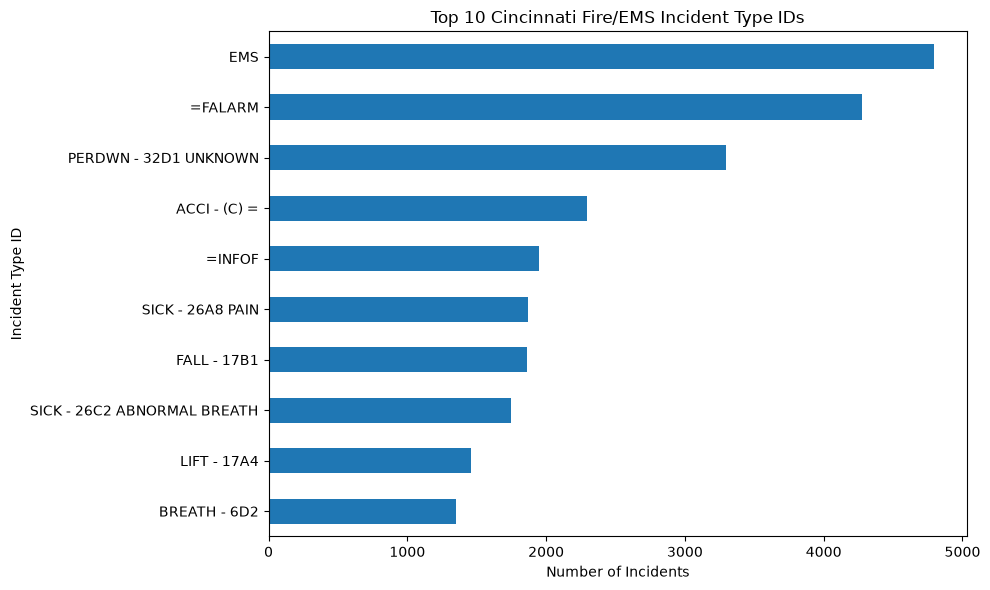

In [9]:
top_incident_types = cleaned_df["INCIDENT_TYPE_ID"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_incident_types.sort_values().plot(kind="barh")
plt.title("Top 10 Cincinnati Fire/EMS Incident Type IDs")
plt.xlabel("Number of Incidents")
plt.ylabel("Incident Type ID")
plt.tight_layout()
plt.show()

## 8. Visualization 2: Incidents by Hour of Day

This chart shows how incident volume changes by hour of day based on incident creation time.

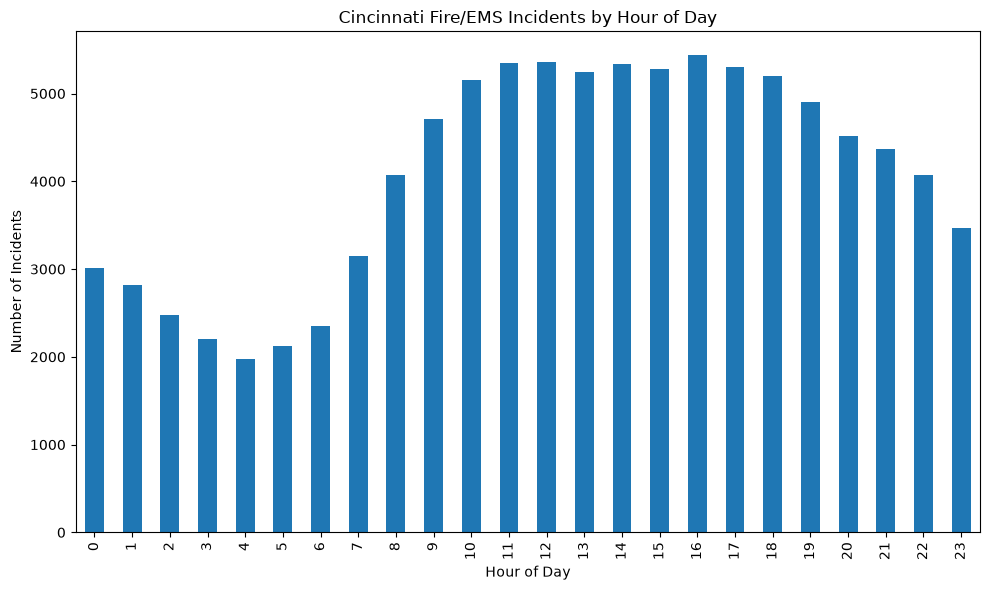

In [10]:
incidents_by_hour = cleaned_df["incident_hour"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
incidents_by_hour.plot(kind="bar")
plt.title("Cincinnati Fire/EMS Incidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

## 9. Visualization 3: Dispatch-to-Arrival Time Distribution

This histogram shows the distribution of dispatch-to-arrival times. The chart filters to values from 0 to 60 minutes to reduce the effect of extreme or invalid values.

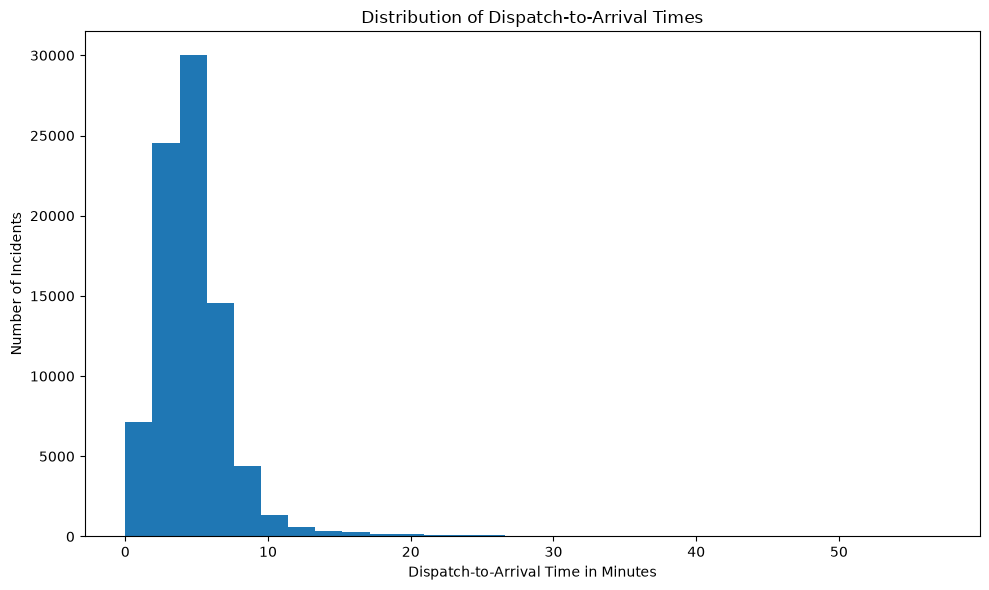

In [11]:
response_times = cleaned_df["dispatch_to_arrival_minutes"].dropna()
response_times = response_times[(response_times >= 0) & (response_times <= 60)]

plt.figure(figsize=(10, 6))
plt.hist(response_times, bins=30)
plt.title("Distribution of Dispatch-to-Arrival Times")
plt.xlabel("Dispatch-to-Arrival Time in Minutes")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

## 10. Summary and Interpretation

Initial findings:

1. The dataset contains real public Cincinnati Fire/EMS incident records with enough rows and columns for a meaningful data workflow.
2. Incident type, disposition, neighborhood, and timestamp fields provide useful structure for exploratory analysis.
3. Several fields contain substantial missing values, especially some descriptive incident type fields, so cleaning and careful column selection are important.
4. Datetime conversion enables time-based analysis, including incident hour and dispatch-to-arrival intervals.
5. The response-time calculation depends on available dispatch and arrival timestamps, so missing or unusual values should be interpreted cautiously.

Limitations and assumptions:

1. This workflow uses public municipal incident data and does not validate operational accuracy against internal department records.
2. Missing values may reflect documentation practices, system exports, or fields that were not used consistently.
3. Dispatch-to-arrival time is a simplified interval and should not be treated as a complete performance measure.
4. This project is limited to data workflow practice and does not provide clinical, operational, or deployment recommendations.

Future integration:

This workflow could support later statistical analysis, machine learning, demand forecasting, and agentic routing projects by creating a repeatable process for loading, cleaning, validating, and summarizing public incident data before more advanced modeling.